#Extension Tasks

##Extension A - Streaming Responses with GROQ

Stream tokens back in real time using the Anthropic client directly. Measure time-to-first-token (perceived responsiveness) vs total latency.

In [ ]:
import time
from groq import Groq

# Initialize your existing Groq client
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
direct_client = Groq(api_key=GROQ_API_KEY)

# Set how many documents to retrieve
TOP_K = 5

def rag_stream_groq(query: str, top_k: int = TOP_K):
    """
    Retrieve context using Azure hybrid search and stream Groq response token-by-token.
    """
    # Stage 1: Retrieve
    raw = azure_hybrid_search(query, top_k=top_k)
    context = "\n\n".join([f"[{r['title']}]\n{r['content']}" for r in raw])
    sources = [r["title"] for r in raw]

    print(f"Query: {query}")
    print(f"Sources: {sources}")
    print("\nAnswer (streaming): ", end="", flush=True)

    # Stage 2: Generate streaming response
    t_start = time.perf_counter()
    first_token_ms = None

    stream = direct_client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {
                "role": "system",
                "content": "Answer ONLY from the provided context. "
                           "If the answer is not present in the context, say so. Be concise."
            },
            {
                "role": "user",
                "content": f"{context}\n\nQuestion: {query}"
            }
        ],
        max_tokens=512,
        temperature=0,
        stream=True
    )

    for chunk in stream:
        delta = chunk.choices[0].delta.content
        if delta:
            if first_token_ms is None:
                first_token_ms = (time.perf_counter() - t_start) * 1000
            print(delta, end="", flush=True)

    total_ms = (time.perf_counter() - t_start) * 1000
    print(f"\n\nTime to first token: {first_token_ms:.0f}ms | Total: {total_ms:.0f}ms\n")

# ============================================================
# Example usage
# ============================================================

rag_stream_groq("What is the attention mechanism in transformer models?")

Query: What is the attention mechanism in transformer models?
Sources: ['Transformer Architecture', 'Large Language Models', 'Transformer Architecture', 'Natural Language Processing', 'Large Language Models']

Answer (streaming): Self-attention, which computes relationships between all tokens simultaneously.

Time to first token: 124ms | Total: 160ms



##Extension B - Confidence Score Filter

Block answers where no retrieved chunk is relevant enough. We gate on FAISS L2 distance from similarity_search_with_score. Lower L2 distance = more similar. Tune L2_THRESHOLD to calibrate.

In [ ]:
# FAISS similarity_search_with_score returns (Document, l2_distance) tuples
# l2_distance is a float32; lower = more similar to the query
# Tune this threshold by inspecting the distribution below
L2_THRESHOLD = 1.0   # reject if best chunk L2 distance > this value

def rag_with_confidence(query: str) -> dict:
    """RAG pipeline that refuses to answer when no chunk is close enough."""
    results_with_scores = faiss_store.similarity_search_with_score(query, k=TOP_K)

    if not results_with_scores:
        return {"answer": "No results found.", "l2_distance": None, "passed": False}

    # scores are numpy float32 -- convert to plain Python float
    best_l2 = float(results_with_scores[0][1])

    if best_l2 > L2_THRESHOLD:
        return {
            "answer": (
                f"I cannot answer this confidently "
                f"(best chunk L2 distance = {best_l2:.3f} > threshold {L2_THRESHOLD}). "
                "Please ask a question related to the topics in the knowledge base."
            ),
            "l2_distance": best_l2,
            "passed": False,
        }

    # Passed threshold -- generate answer
    docs    = [doc for doc, _ in results_with_scores]
    context = "\n\n".join([f"[{d.metadata['title']}]\n{d.page_content}" for d in docs])
    messages = [
        SystemMessage(content="Answer ONLY from the provided context."),
        HumanMessage(content=f"\n{context}\n\n\n{query}"),
    ]
    response = llm.invoke(messages)
    return {"answer": response.content, "l2_distance": best_l2, "passed": True}


# Test with in-corpus and out-of-corpus queries
test_queries = [
    ("What is the attention mechanism in transformers?",   "In-corpus -- should PASS"),
    ("How does CRISPR cut DNA?",                           "In-corpus -- should PASS"),
    ("What is the boiling point of tungsten carbide?",     "Out-of-corpus -- should BLOCK"),
    ("Recommend a good restaurant in Tokyo",               "Out-of-corpus -- should BLOCK"),
]

print(f"Confidence filter (L2 threshold = {L2_THRESHOLD})\n")
for query, label in test_queries:
    result = rag_with_confidence(query)
    status = "PASSED" if result["passed"] else "BLOCKED"
    l2_str = f"{result['l2_distance']:.3f}" if result["l2_distance"] is not None else "N/A"
    print(f"[{status}] {label}")
    print(f"  Q: {query}")
    print(f"  L2={l2_str}  A: {result['answer'][:130]}...\n")


Confidence filter (L2 threshold = 1.0)

[BLOCKED] In-corpus -- should PASS
  Q: What is the attention mechanism in transformers?
  L2=1.020  A: I cannot answer this confidently (best chunk L2 distance = 1.020 > threshold 1.0). Please ask a question related to the topics in ...

[PASSED] In-corpus -- should PASS
  Q: How does CRISPR cut DNA?
  L2=0.647  A: CRISPR-Cas9 cuts DNA by using a guide RNA (gRNA) to direct the Cas9 enzyme to a specific DNA sequence, where it cuts both strands ...

[BLOCKED] Out-of-corpus -- should BLOCK
  Q: What is the boiling point of tungsten carbide?
  L2=1.612  A: I cannot answer this confidently (best chunk L2 distance = 1.612 > threshold 1.0). Please ask a question related to the topics in ...

[BLOCKED] Out-of-corpus -- should BLOCK
  Q: Recommend a good restaurant in Tokyo
  L2=1.646  A: I cannot answer this confidently (best chunk L2 distance = 1.646 > threshold 1.0). Please ask a question related to the topics in ...



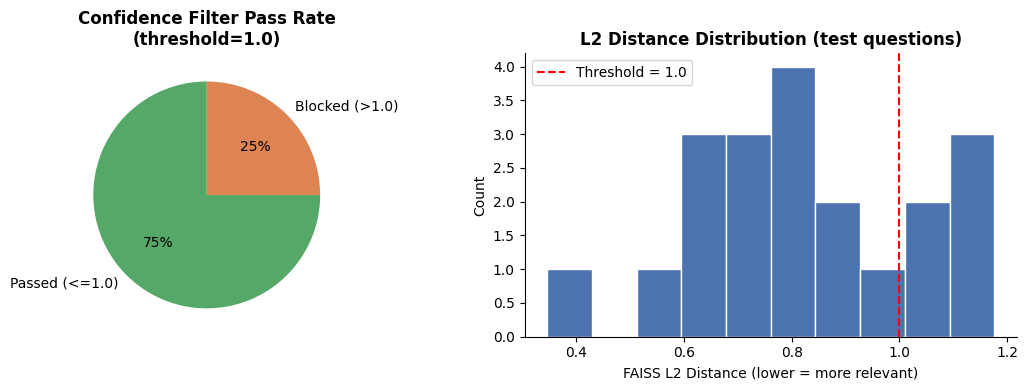

15/20 test questions passed the confidence filter


In [ ]:
# Analyse L2 distance distribution on all 20 test questions
l2_scores = []
pass_flags = []
for q in TEST_QUESTIONS:
    res = faiss_store.similarity_search_with_score(q, k=1)
    l2  = float(res[0][1]) if res else float("inf")
    l2_scores.append(l2)
    pass_flags.append(l2 <= L2_THRESHOLD)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Pass/fail pie
passed = sum(pass_flags)
ax1.pie(
    [passed, len(pass_flags) - passed],
    labels=[f"Passed (<={L2_THRESHOLD})", f"Blocked (>{L2_THRESHOLD})"],
    colors=["#55A868", "#DD8452"],
    autopct="%1.0f%%",
    startangle=90,
)
ax1.set_title(f"Confidence Filter Pass Rate\n(threshold={L2_THRESHOLD})", fontweight="bold")

# L2 score histogram
ax2.hist(l2_scores, bins=10, color="#4C72B0", edgecolor="white")
ax2.axvline(L2_THRESHOLD, color="red", linestyle="--", linewidth=1.5,
            label=f"Threshold = {L2_THRESHOLD}")
ax2.set_title("L2 Distance Distribution (test questions)", fontweight="bold")
ax2.set_xlabel("FAISS L2 Distance (lower = more relevant)")
ax2.set_ylabel("Count")
ax2.legend()
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("confidence_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"{passed}/{len(pass_flags)} test questions passed the confidence filter")